### Ejercicios Prácticos: ¿Qué es la IA Agéntica?
🎯 Plan de Lección: De los Sistemas Basados en Reglas a los Agentes Autónomos

Esta lección ofrece ejercicios prácticos que demuestran la evolución desde sistemas simples basados en reglas hasta sofisticados agentes impulsados por LLM, ayudando a los estudiantes a comprender el espectro "autónomo" frente a "agéntico".
Requisitos previos: Configuración básica

### Bibliotecas Principales Utilizadas
OS: Accede a las variables de entorno para una gestión segura de la clave de API sin codificar las credenciales directamente en el código

JSON: Maneja la serialización y deserialización de datos para dar formato a las solicitudes y respuestas de la API

OpenAI: Proporciona la interfaz de cliente estandarizada para comunicarse con las API de los modelos de lenguaje

In [2]:
# config.py - Basic configuration
import os
import json
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
)

## Ejercicio 1: Sistema Basado en Reglas (La Base)

### Concepto: Los sistemas tradicionales basados en reglas siguen instrucciones explícitas y predeterminadas, sin capacidad de adaptación ni comprensión.

### Descripción Breve
Este código implementa un sistema tradicional de atención al cliente basado en reglas que usa coincidencia explícita de patrones para generar respuestas. Demuestra cómo operaban los sistemas de automatización previos a la IA, usando lógica fija de tipo if-else sin ninguna capacidad de aprendizaje automático ni de comprensión del lenguaje natural.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El script crea un sistema de atención al cliente que procesa las entradas del usuario buscando patrones de palabras clave predefinidos en el texto. Cuando un usuario envía un mensaje, el sistema recorre su diccionario de reglas buscando palabras clave coincidentes. Si las encuentra, devuelve la respuesta predefinida correspondiente. Si no hay coincidencias, ofrece una respuesta por defecto de reserva. Todo el flujo de trabajo depende de la coincidencia exacta de cadenas, sin ninguna comprensión del contexto ni del significado.

### Diagrama de Flujo Visual
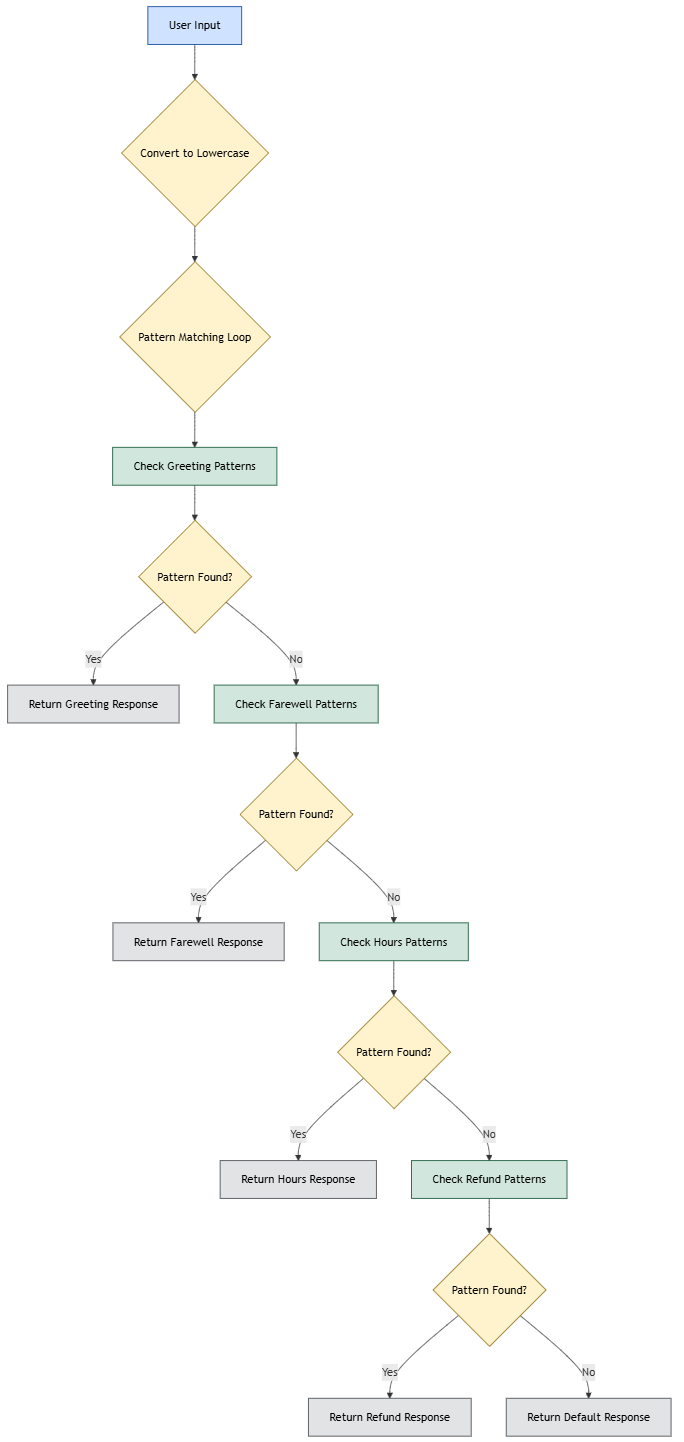

## Desglose del Código Paso a Paso

### Inicialización del Sistema
- La clase RuleBasedCustomerService se inicializa con un diccionario completo de reglas
- Cada categoría de intención (saludo, despedida, horario, reembolso) contiene patrones y sus respuestas correspondientes
- Se define una respuesta por defecto para las entradas sin coincidencia

### Lógica de Procesamiento de Mensajes
- La entrada del usuario se convierte a minúsculas para una coincidencia insensible a mayúsculas
- El sistema itera a través de todas las reglas excepto la regla por defecto
- Para cada regla, comprueba si algún patrón existe dentro de la entrada del usuario
- La primera coincidencia encontrada dispara la respuesta correspondiente

### Mecanismo de Coincidencia de Patrones
- Usa coincidencia simple de subcadenas (patrón dentro de la entrada del usuario)
- Sin comprensión semántica ni conciencia del contexto
- Devuelve exactamente la misma respuesta para los patrones coincidentes, independientemente de la variación en la entrada

### Generación de Respuestas
- Devuelve una respuesta estructurada que contiene el tipo de sistema, el texto de entrada, el patrón coincidente, la respuesta y los metadatos
- Siempre devuelve una puntuación de confianza de 1.0, ya que las reglas son deterministas
- Indica explícitamente la nula flexibilidad en las capacidades del sistema

### Función de Demostración
- Prueba el sistema con varias entradas de muestra, incluyendo consultas válidas y casos límite
- Muestra tanto coincidencias exitosas como respuestas por defecto para entradas no reconocidas
- Demuestra las limitaciones del sistema ante consultas complejas o inesperadas

### Conexión con la Lección
- Sistemas Deterministas: Este código ilustra perfectamente cómo operan los sistemas tradicionales basados en reglas, con un comportamiento fijo y predecible, tal como se discutió en la clase
- Limitaciones de la Coincidencia de Patrones: Demuestra la fragilidad de los enfoques basados en palabras clave, que no pueden manejar sinónimos, paráfrasis ni comprensión contextual
- Aprendizaje Zero-Shot: Muestra sistemas sin capacidad para manejar entradas no vistas, en contraste con los sistemas de IA modernos que pueden generalizar
- Propagación de Errores: Destaca cómo la falta de patrones conduce a respuestas incorrectas, y cómo añadir nuevas reglas requiere esfuerzo manual
- Sobrecarga de Mantenimiento: Ilustra el problema de escalabilidad: cada nuevo escenario requiere programación explícita
- Puntuación de Confianza: Muestra cómo los sistemas basados en reglas suelen tener una confianza binaria (1.0 o 0), a diferencia de los sistemas de IA probabilísticos
- Cumplimiento de la Lógica de Negocio: Demuestra cómo las reglas pueden hacer cumplir de forma fiable procesos y respuestas de negocio específicos

In [3]:
# rule_based_system.py
class RuleBasedCustomerService:
    """
    A traditional rule-based system that follows explicit if-else logic.
    Represents pre-AI automation systems.
    """

    def __init__(self):
        self.rules = {
            "greeting": {
                "patterns": ["hello", "hi", "hey", "greetings"],
                "response": "Hello! How can I help you today?"
            },
            "farewell": {
                "patterns": ["bye", "goodbye", "see you", "exit"],
                "response": "Thank you for contacting us. Have a great day!"
            },
            "hours": {
                "patterns": ["hours", "open", "close", "time"],
                "response": "We're open Monday-Friday, 9 AM to 5 PM."
            },
            "refund": {
                "patterns": ["refund", "return", "money back"],
                "response": "Please provide your order number for refund processing."
            },
            "default": {
                "response": "I'm sorry, I don't understand. Please contact a human agent."
            }
        }

    def process_message(self, user_input):
        """Process input using strict pattern matching"""
        user_input = user_input.lower()

        # Exact pattern matching - no understanding of meaning
        for intent, rule in self.rules.items():
            if intent == "default":
                continue

            for pattern in rule["patterns"]:
                if pattern in user_input:
                    return {
                        "system_type": "Rule-Based",
                        "input": user_input,
                        "matched_pattern": pattern,
                        "response": rule["response"],
                        "confidence": 1.0,  # Always certain with rules
                        "flexibility": "None"
                    }

        # No pattern matched
        return {
            "system_type": "Rule-Based",
            "input": user_input,
            "matched_pattern": "None",
            "response": self.rules["default"]["response"],
            "confidence": 1.0,
            "flexibility": "None"
        }

# Demonstrate the rule-based system
def demo_rule_based():
    print("=== Rule-Based System Demo ===")
    system = RuleBasedCustomerService()

    test_inputs = [
        "Hello there!",
        "What are your hours?",
        "I want a refund for my purchase",
        "Can you help me with a complex technical issue?",
        "What's the weather like today?"
    ]

    for user_input in test_inputs:
        result = system.process_message(user_input)
        print(f"\nInput: {user_input}")
        print(f"Response: {result['response']}")
        print(f"Matched: {result['matched_pattern']}")
        print(f"Flexibility: {result['flexibility']}")

demo_rule_based()

=== Rule-Based System Demo ===

Input: Hello there!
Response: Hello! How can I help you today?
Matched: hello
Flexibility: None

Input: What are your hours?
Response: We're open Monday-Friday, 9 AM to 5 PM.
Matched: hours
Flexibility: None

Input: I want a refund for my purchase
Response: Please provide your order number for refund processing.
Matched: refund
Flexibility: None

Input: Can you help me with a complex technical issue?
Response: I'm sorry, I don't understand. Please contact a human agent.
Matched: None
Flexibility: None

Input: What's the weather like today?
Response: I'm sorry, I don't understand. Please contact a human agent.
Matched: None
Flexibility: None


## Aprendizaje Clave: Los sistemas basados en reglas son deterministas, pero carecen de comprensión y flexibilidad.

### Ejercicio 2: Sistema LLM Básico (El Extremo "Autónomo")

### Concepto: Los LLM pueden generar texto similar al humano, pero operan sin objetivos persistentes ni memoria; son más reactivos que proactivos.

### Descripción Breve
Este código implementa un asistente básico basado en un Modelo de Lenguaje Grande (LLM) que genera respuestas contextuales a la vez que demuestra las limitaciones clave de los sistemas de IA no agénticos. Muestra cómo los LLM pueden manejar el lenguaje natural sin memoria persistente ni comportamiento orientado a objetivos, representando el extremo "autónomo pero sin rumbo" del espectro de la IA.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El script crea un asistente impulsado por LLM que procesa las entradas del usuario manteniendo un historial de conversación a corto plazo y generando respuestas contextuales mediante un modelo de lenguaje preentrenado. A diferencia de los sistemas basados en reglas, puede comprender variaciones del lenguaje natural y generar respuestas similares a las humanas, pero carece de memoria persistente, objetivos a largo plazo y verdadera agencia. El sistema opera de forma reactiva, centrándose solo en la consulta inmediata sin mantener el contexto a lo largo de conversaciones extensas.

### Diagrama de Flujo Visual
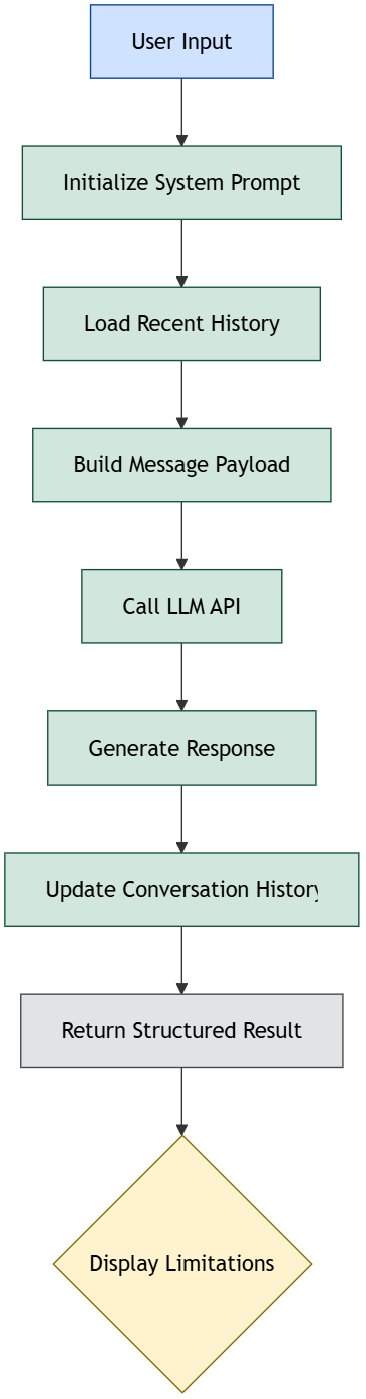

## Desglose del Código Paso a Paso

### Inicialización del Sistema
- Crea una lista de historial de conversación para rastrear las interacciones recientes
- Configura la arquitectura básica para mantener el contexto de la sesión
- Prepara el sistema para manejar entradas secuenciales del usuario

### Proceso de Generación de Respuestas
- Construye un prompt de sistema que define el rol y las limitaciones del asistente
- Construye una carga de mensajes que combina las instrucciones del sistema, el historial reciente y la entrada actual
- Limita el historial de conversación a los últimos tres intercambios para mantener la ventana de contexto
- Añade la consulta actual del usuario a la secuencia de mensajes

### Interacción con el LLM
- Envía la carga de mensajes construida al modelo
- Usa un ajuste de temperatura de 0.7 para equilibrar creatividad y consistencia
- Procesa la respuesta generada por el LLM a través del cliente de la API
- Extrae el contenido de texto de la respuesta de finalización del modelo

### Gestión del Historial
- Actualiza el historial de conversación tanto con la entrada del usuario como con la respuesta del asistente
- Mantiene solo los intercambios recientes para simular una memoria de trabajo limitada
- Asegura que el contexto se mantenga dentro de límites manejables para el modelo
- Proporciona la ilusión de memoria a corto plazo sin verdadera persistencia

### Empaquetado del Resultado
- Devuelve una respuesta estructurada que contiene el tipo de sistema y el texto generado
- Enumera explícitamente las capacidades y limitaciones del sistema
- Incluye una evaluación del nivel de agencia para resaltar su naturaleza reactiva
- Proporciona metadatos sobre las características operativas del sistema

### Función de Demostración
- Prueba el sistema con una secuencia de conversaciones que revelan las limitaciones de memoria
- Muestra cómo el asistente maneja información y preferencias personales
- Demuestra la incapacidad de recordar el contexto previo o de mantener hechos persistentes
- Resalta la naturaleza reactiva, en lugar de proactiva, de los sistemas LLM básicos

### Conexión con la Lección
- IA Autónoma pero Sin Rumbo: Demuestra el concepto, visto en clase, de sistemas que pueden generar respuestas coherentes pero carecen de agencia con propósito
- Limitaciones de la Ventana de Contexto: Muestra cómo las restricciones de memoria afectan la continuidad de la conversación y la personalización
- Sistemas Reactivos frente a Proactivos: Ilustra la diferencia entre responder a consultas inmediatas y perseguir objetivos a largo plazo
- Memoria a Corto Plazo: Ejemplifica el concepto de retención limitada de contexto en las arquitecturas LLM actuales
- Temperatura y Creatividad: Conecta con la discusión en clase sobre el control de la variabilidad y el determinismo de las respuestas
- Ingeniería de Prompts de Sistema: Muestra cómo las instrucciones iniciales moldean el comportamiento del modelo sin cambiar sus capacidades subyacentes
- Sistemas de IA basados en API: Demuestra la implementación práctica de la integración de modelos de lenguaje en la nube
- Limitaciones de los Sistemas sin Estado: Resalta los desafíos de construir agentes conversacionales persistentes con la tecnología actual
- Reconocimiento de Patrones frente a Comprensión Real: Ilustra la diferencia entre la coincidencia estadística de patrones y la comprensión genuina

In [4]:
# basic_llm_system.py

class BasicLLMAssistant:
    """
    A basic LLM system that generates responses but lacks agency.
    Represents the 'autonomous' end of the spectrum - capable but directionless.
    """

    def __init__(self):
        self.conversation_history = []

    def generate_response(self, user_input, context=None):
        """Generate response using LLM without persistent goals"""

        system_prompt = """
        You are a helpful customer service assistant. Answer the user's question directly and helpfully.
        You don't have memory of previous conversations or long-term goals.
        Focus only on the current query.
        """

        # Build conversation context (limited to current session)
        messages = [{"role": "system", "content": system_prompt}]

        # Add limited conversation history
        for msg in self.conversation_history[-3:]:  # Only last 3 exchanges
            messages.append(msg)

        messages.append({"role": "user", "content": user_input})

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=messages,
            temperature=0.7
        )

        llm_response = response.choices[0].message.content

        # Update conversation history
        self.conversation_history.append({"role": "user", "content": user_input})
        self.conversation_history.append({"role": "assistant", "content": llm_response})

        return {
            "system_type": "Basic LLM (Autonomous)",
            "input": user_input,
            "response": llm_response,
            "capabilities": ["Text Generation", "Pattern Recognition"],
            "limitations": ["No Memory", "No Goals", "Reactive Only"],
            "agency_level": "Low"
        }

# Demonstrate basic LLM system
def demo_basic_llm():
    print("\n=== Basic LLM System Demo ===")
    assistant = BasicLLMAssistant()

    # Simulate a conversation that shows limitations
    conversations = [
        "Hello, my name is Alice. I need help with my account.",
        "What's my name?",
        "Can you remember that I prefer email communication?",
        "What did I ask about earlier?"
    ]

    for user_input in conversations:
        result = assistant.generate_response(user_input)
        print(f"\nInput: {user_input}")
        print(f"Response: {result['response'][:100]}...")
        print(f"Limitations: {result['limitations']}")
        print(f"Agency Level: {result['agency_level']}")

demo_basic_llm()


=== Basic LLM System Demo ===

Input: Hello, my name is Alice. I need help with my account.
Response: Hello Alice! I’d be happy to help you with your account. Could you please provide more details about...
Limitations: ['No Memory', 'No Goals', 'Reactive Only']
Agency Level: Low

Input: What's my name?
Response: Your name is Alice. How can I assist you further with your account?...
Limitations: ['No Memory', 'No Goals', 'Reactive Only']
Agency Level: Low

Input: Can you remember that I prefer email communication?
Response: I'm sorry, but I can't remember preferences or past conversations. However, I can assist you with an...
Limitations: ['No Memory', 'No Goals', 'Reactive Only']
Agency Level: Low

Input: What did I ask about earlier?
Response: I'm sorry, but I don't have the ability to recall previous conversations. How can I assist you with ...
Limitations: ['No Memory', 'No Goals', 'Reactive Only']
Agency Level: Low


## Aprendizaje Clave: Los LLM básicos son potentes, pero carecen de persistencia y propósito.

### Ejercicio 3: Sistema de IA Agéntica (El Extremo "Agéntico")

### Concepto: Los sistemas de IA agéntica tienen objetivos, memoria y pueden ejecutar acciones con propósito utilizando herramientas.

### Descripción Breve
Este código implementa un verdadero sistema de IA agéntica que demuestra comportamiento orientado a objetivos, memoria persistente y uso de herramientas. Muestra cómo los sistemas de IA pueden ir más allá de las respuestas reactivas para convertirse en asistentes proactivos y con propósito, que mantienen objetivos a largo plazo y utilizan herramientas externas para realizar tareas.

### Bibliotecas Principales Utilizadas
JSON: Para analizar y generar formatos de datos estructurados entre las fases de planificación y ejecución
Datetime: Para marcar las acciones con su hora y crear identificadores únicos
Cliente LLM: Interfaz con el modelo de lenguaje tanto para la planificación como para la generación de respuestas

### Lógica del Código y Flujo: Visión General de Alto Nivel
El script crea un agente de IA avanzado que opera a través de un flujo de trabajo estructurado de planificar-ejecutar-responder. A diferencia de los sistemas LLM básicos, este agente mantiene memoria persistente, persigue objetivos a largo plazo y utiliza diversas herramientas para realizar tareas. El sistema comienza analizando la entrada del usuario en relación con sus objetivos principales, luego crea un plan de ejecución, usa las herramientas apropiadas para recopilar información o ejecutar acciones, y finalmente genera respuestas que hacen avanzar sus objetivos generales a la vez que atienden las necesidades inmediatas del usuario.

### Diagrama de Flujo Visual
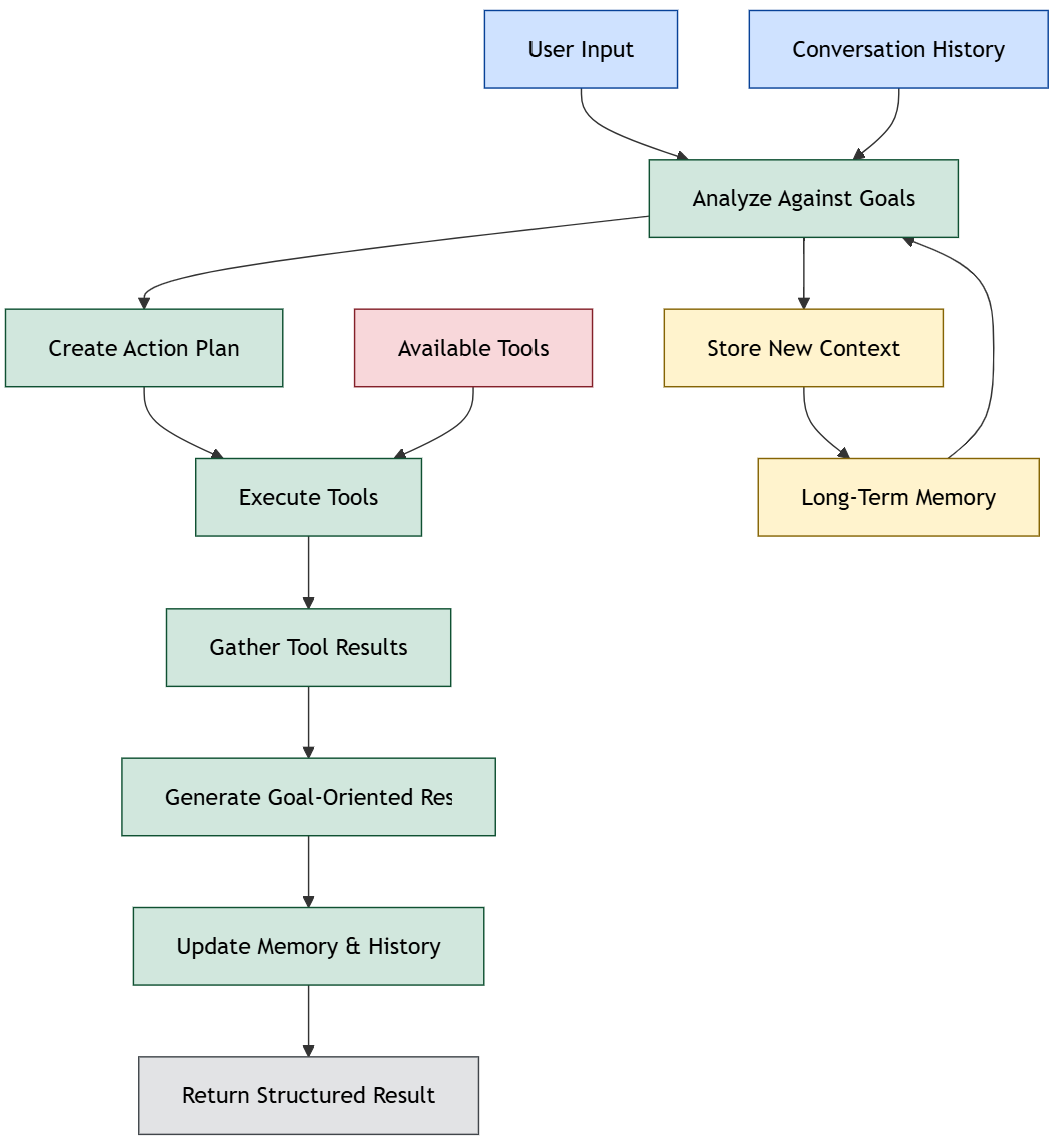

## Desglose del Código Paso a Paso

### Inicialización y Arquitectura del Sistema
- Establece objetivos principales que guían todas las interacciones y la toma de decisiones
- Establece un almacenamiento de memoria a largo plazo para la retención persistente de información
- Mantiene un historial de conversación para la comprensión contextual
- Registra las herramientas disponibles, incluyendo la búsqueda de clientes, la actualización de preferencias, la creación de tickets y el escalado a un humano

### Conjunto de Herramientas Implementadas
- La búsqueda de información del cliente simula consultas a una base de datos con datos de cliente ficticios
- La actualización de preferencias modifica la memoria a largo plazo con ajustes específicos del usuario
- La creación de tickets de soporte genera identificadores únicos con marcas de tiempo
- El escalado a un humano deriva los problemas complejos a agentes humanos con niveles de prioridad

### Fase de Planificación Estratégica
- Analiza la entrada del usuario en relación con los objetivos del sistema y el contexto de la conversación
- Crea planes de acción estructurados en JSON que especifican los objetivos inmediatos y las herramientas requeridas
- Determina qué información debe recordarse para futuras interacciones
- Usa un ajuste de temperatura más bajo para decisiones de planificación consistentes y fiables

### Mecanismo de Ejecución del Plan
- Itera a través de las herramientas planificadas en secuencia
- Identifica el contexto relevante del cliente a partir de la entrada del usuario
- Ejecuta las herramientas apropiadas con parámetros conscientes del contexto
- Captura y agrega los resultados de todas las ejecuciones de herramientas
- Actualiza la memoria a largo plazo con información estratégicamente importante

### Generación de Respuestas Orientadas a Objetivos
- Combina el contexto del plan, los resultados de las herramientas y el historial de conversación
- Genera respuestas que atienden tanto las necesidades inmediatas como los objetivos a largo plazo
- Mantiene la consistencia con el contexto y las preferencias establecidos previamente
- Usa una temperatura más alta para un flujo de conversación natural y adaptable

### Demostración y Evaluación
- Prueba el sistema con conversaciones que requieren memoria y uso de herramientas
- Muestra cómo el agente mantiene las preferencias del cliente a lo largo de las interacciones
- Demuestra un comportamiento proactivo al construir relaciones a largo plazo
- Resalta la capacidad del sistema para recordar y utilizar la información almacenada

### Conexión con la Lección
- Verdadera Agencia: Demuestra el concepto, visto en clase, de sistemas de IA con un comportamiento orientado a objetivos y con propósito, en lugar de respuestas reactivas
- Uso de Herramientas e Integración de API: Muestra la implementación práctica de la discusión en clase sobre sistemas de IA que interactúan con servicios y bases de datos externos
- Memoria Persistente: Ilustra cómo los sistemas agénticos mantienen el contexto y las preferencias a lo largo de múltiples interacciones, abordando las limitaciones de memoria de los LLM básicos
- Ciclo de Planificación y Ejecución: Ejemplifica la arquitectura percibir-planificar-actuar discutida en la teoría de sistemas autónomos
- Comportamiento Orientado a Objetivos: Conecta con el contenido de la clase sobre sistemas que persiguen objetivos a largo plazo en lugar de solo responder consultas inmediatas
- Razonamiento Estructurado: Demuestra el uso de la planificación basada en JSON y la selección de herramientas como una forma de razonamiento sistemático
- Colaboración Humano-IA: Muestra mecanismos de escalado que reconocen cuándo es necesaria la intervención humana
- Control de Temperatura para Diferentes Tareas: Ilustra cómo variar los niveles de creatividad sirve a diferentes propósitos en la planificación frente a la generación de respuestas
- Resolución de Problemas en Múltiples Pasos: Encarna la discusión de la clase sobre sistemas que descomponen tareas complejas en secuencias de acciones planificadas

In [5]:
# agentic_system.py
import json
from datetime import datetime

class AgenticAISystem:
    """
    A true agentic AI system with goals, memory, and tool usage.
    Represents the 'agentic' end of the spectrum - purposeful and proactive.
    """

    def __init__(self, primary_goal="Provide excellent customer service"):
        self.primary_goal = primary_goal
        self.long_term_memory = {}  # Persistent storage
        self.conversation_history = []
        self.available_tools = {
            "lookup_customer_info": self.lookup_customer_info,
            "update_customer_preferences": self.update_customer_preferences,
            "create_support_ticket": self.create_support_ticket,
            "escalate_to_human": self.escalate_to_human
        }

        # Initialize with some memory
        self.long_term_memory["system_goals"] = [primary_goal]
        self.long_term_memory["customer_preferences"] = {}

    def lookup_customer_info(self, customer_id):
        """Simulate tool for looking up customer information"""
        # In real system, this would query a database
        mock_database = {
            "alice123": {"name": "Alice Smith", "tier": "premium", "preferences": {"contact_method": "email"}},
            "bob456": {"name": "Bob Johnson", "tier": "standard", "preferences": {"contact_method": "phone"}}
        }
        return mock_database.get(customer_id, {"error": "Customer not found"})

    def update_customer_preferences(self, customer_id, preferences):
        """Simulate tool for updating customer preferences"""
        if customer_id not in self.long_term_memory["customer_preferences"]:
            self.long_term_memory["customer_preferences"][customer_id] = {}

        self.long_term_memory["customer_preferences"][customer_id].update(preferences)
        return {"status": "success", "updated_preferences": preferences}

    def create_support_ticket(self, customer_id, issue_description):
        """Simulate tool for creating support tickets"""
        ticket_id = f"TICKET_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        return {
            "status": "success",
            "ticket_id": ticket_id,
            "message": f"Support ticket created for {customer_id}"
        }

    def escalate_to_human(self, customer_id, reason):
        """Simulate escalation tool"""
        return {
            "status": "escalated",
            "assigned_to": "human_agent",
            "reason": reason,
            "priority": "high" if "urgent" in reason.lower() else "medium"
        }

    def plan_action(self, user_input, context):
        """Agent plans its action based on goals and context"""

        planning_prompt = f"""
        You are an agentic AI system with the primary goal: "{self.primary_goal}"

        Current conversation context: {context}
        Long-term goals: {self.long_term_memory['system_goals']}

        Analyze the user's input and plan your action. Consider:
        1. What is the user's immediate need?
        2. How does this relate to your long-term goals?
        3. What tools might be helpful?
        4. Should you remember anything for future interactions?

        Available tools: {list(self.available_tools.keys())}

        Respond with a JSON plan:
        {{
            "immediate_goal": "specific goal for this interaction",
            "tools_needed": ["tool1", "tool2"],
            "remember_for_future": "key information to store",
            "response_strategy": "how to approach the response"
        }}
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": planning_prompt}],
            temperature=0.3
        )

        try:
            return json.loads(response.choices[0].message.content)
        except:
            return {"immediate_goal": "help user", "tools_needed": [], "remember_for_future": ""}

    def execute_plan(self, user_input, plan):
        """Execute the planned action using tools"""
        tool_results = {}

        for tool_name in plan.get("tools_needed", []):
            if tool_name in self.available_tools:
                # Identify the customer if mentioned
                customer_id = "alice123" if "alice" in user_input.lower() else "bob456"

                if tool_name == "lookup_customer_info":
                    tool_results[tool_name] = self.lookup_customer_info(customer_id)

                elif tool_name == "update_customer_preferences":
                    # Just simulate a preference update
                    preferences = {"contact_method": "email"} if "email" in user_input.lower() else {"contact_method": "phone"}
                    tool_results[tool_name] = self.update_customer_preferences(customer_id, preferences)

                elif tool_name == "create_support_ticket":
                    issue_description = user_input
                    tool_results[tool_name] = self.create_support_ticket(customer_id, issue_description)

                elif tool_name == "escalate_to_human":
                    reason = user_input
                    tool_results[tool_name] = self.escalate_to_human(customer_id, reason)

                else:
                    tool_results[tool_name] = {"error": f"Unknown tool {tool_name}"}

            # Store information for future if needed
            if plan.get("remember_for_future"):
                self.long_term_memory["recent_context"] = plan["remember_for_future"]

            return tool_results


    def generate_agentic_response(self, user_input):
        """Complete agentic workflow: Plan → Execute → Respond"""

        # Build context from conversation history
        context = " | ".join([f"{msg['role']}: {msg['content']}"
                            for msg in self.conversation_history[-2:]])

        # Step 1: Plan action based on goals
        plan = self.plan_action(user_input, context)
        print(f"🤖 AGENT PLAN: {plan}")

        # Step 2: Execute planned actions with tools
        tool_results = self.execute_plan(user_input, plan)
        print(f"🛠️ TOOL RESULTS: {tool_results}")

        # Step 3: Generate response considering goals and tool results
        response_prompt = f"""
        You are an agentic AI system with goals and memory.

        Primary Goal: {self.primary_goal}
        Current Plan: {plan}
        Tool Results: {tool_results}
        Conversation History: {context}

        User's current input: {user_input}

        Generate a response that:
        1. Addresses the user's immediate need
        2. Advances your long-term goals
        3. Incorporates information from tools used
        4. Maintains context from previous interactions
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": response_prompt}],
            temperature=0.7
        )

        agent_response = response.choices[0].message.content

        # Update conversation history
        self.conversation_history.append({"role": "user", "content": user_input})
        self.conversation_history.append({"role": "assistant", "content": agent_response})

        return {
            "system_type": "Agentic AI System",
            "input": user_input,
            "response": agent_response,
            "plan": plan,
            "tool_results": tool_results,
            "capabilities": ["Goal-Oriented", "Tool Usage", "Memory", "Planning"],
            "agency_level": "High",
            "long_term_goals": self.long_term_memory["system_goals"]
        }

# Demonstrate agentic AI system
def demo_agentic_ai():
    print("\n=== Agentic AI System Demo ===")
    agent = AgenticAISystem("Build long-term customer relationships and resolve issues efficiently")

    # Simulate a conversation that shows agentic capabilities
    conversations = [
        "Hello, my name is Alice. I'm having trouble with my recent order.",
        "Can you remember that I prefer email for updates?",
        "Actually, I need help with a billing question from last month.",
        "What's my preferred contact method again?"
    ]

    for user_input in conversations:
        print(f"\n{'='*50}")
        print(f"User: {user_input}")
        result = agent.generate_agentic_response(user_input)
        print(f"Agent: {result['response']}")
        print(f"Capabilities: {result['capabilities']}")
        print(f"Agency Level: {result['agency_level']}")

demo_agentic_ai()


=== Agentic AI System Demo ===

User: Hello, my name is Alice. I'm having trouble with my recent order.
🤖 AGENT PLAN: {'immediate_goal': 'help user', 'tools_needed': [], 'remember_for_future': ''}
🛠️ TOOL RESULTS: None
Agent: Hello Alice! I'm here to help you with your recent order. Could you please provide me with some details about the issue you're experiencing? This way, I can assist you more effectively and ensure we resolve it quickly. Your satisfaction is important to me, and I want to make sure we build a positive relationship moving forward!
Capabilities: ['Goal-Oriented', 'Tool Usage', 'Memory', 'Planning']
Agency Level: High

User: Can you remember that I prefer email for updates?
🤖 AGENT PLAN: {'immediate_goal': 'Understand the specific issue Alice is facing with her recent order and provide a resolution.', 'tools_needed': ['lookup_customer_info', 'create_support_ticket'], 'remember_for_future': "Alice's preferences and any specific issues related to her order history.", 'r


## Aprendizaje Clave: Los sistemas agénticos tienen propósito, usan herramientas, mantienen memoria y trabajan hacia objetivos.

### Ejercicio 4: El Visualizador del Espectro

### Concepto: Comparar los tres sistemas lado a lado para comprender el espectro de autonomía.

### Descripción Breve
Este código implementa un marco de comparación integral que analiza tres sistemas de IA diferentes a lo largo del espectro de autonomía. Demuestra cómo los sistemas basados en reglas, los LLM básicos y la IA agéntica manejan las mismas entradas, resaltando sus distintas capacidades, limitaciones y posiciones en el continuo de autonomía mediante pruebas y evaluación sistemáticas.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El script crea un marco de análisis que prueba sistemáticamente tres arquitecturas de IA distintas con escenarios de entrada idénticos. Inicializa los tres sistemas —basado en reglas, LLM básico e IA agéntica— y luego ejecuta una serie de casos de prueba a través de cada sistema simultáneamente. El marco captura y compara sus respuestas, capacidades y características de comportamiento, proporcionando una vista lado a lado de cómo los sistemas en diferentes niveles de autonomía abordan los mismos problemas.

### Diagrama de Flujo Visual
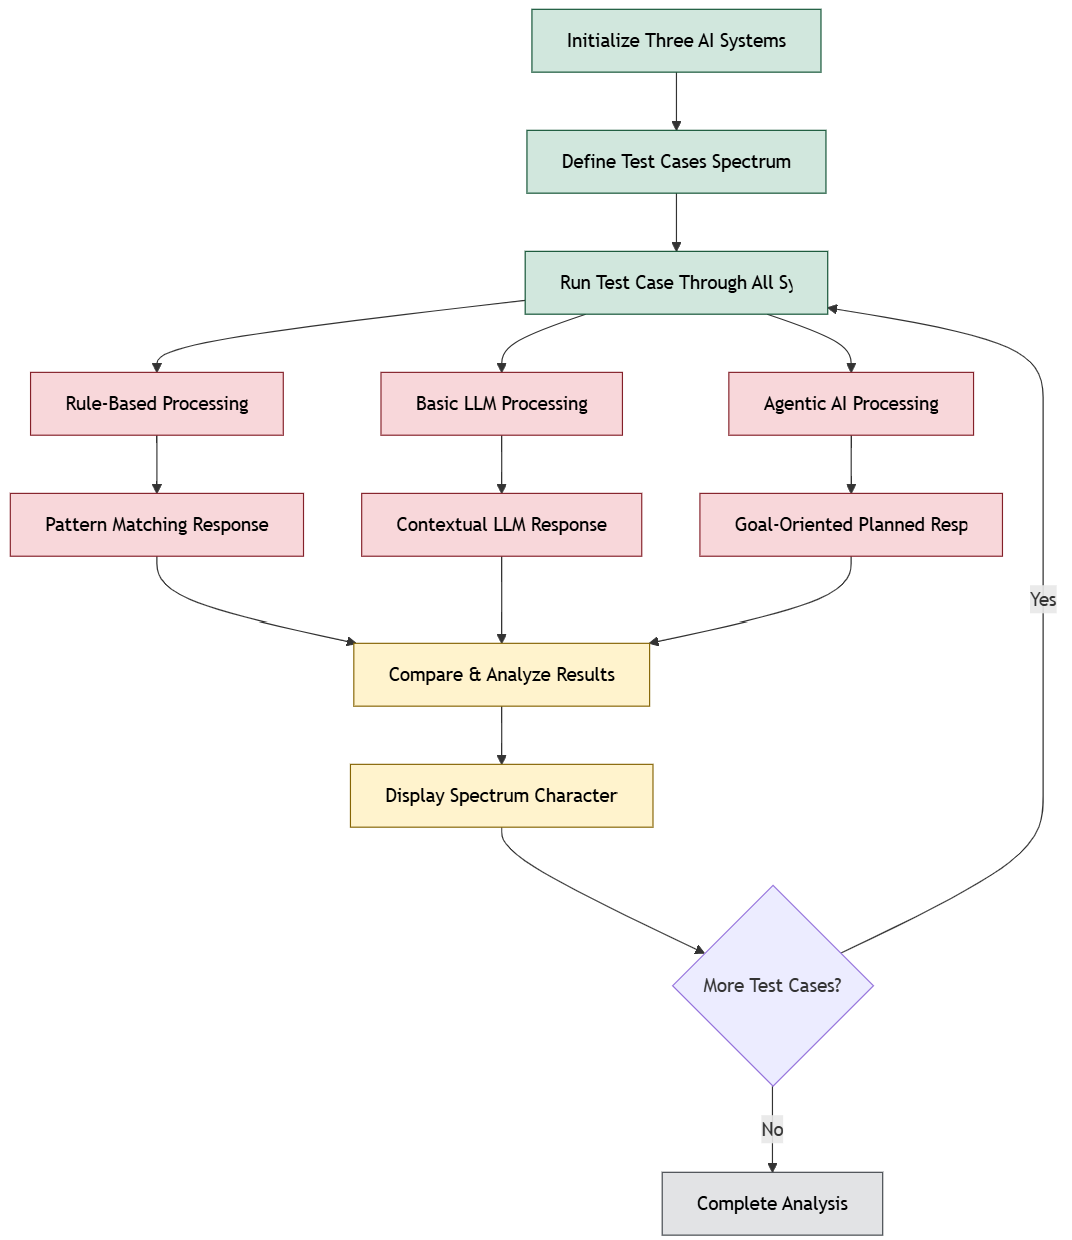

## Desglose del Código Paso a Paso

### Fase de Inicialización del Sistema
- Crea instancias de los tres tipos de sistemas de IA simultáneamente
- Establece la base para el análisis comparativo entre arquitecturas
- Prepara el entorno de pruebas con igual acceso a todos los sistemas

### Marco de Análisis Unificado
- Implementa un método estandarizado para procesar entradas a través de los diferentes tipos de sistemas
- Maneja las variaciones de interfaz entre los sistemas basados en reglas, LLM y agénticos
- Asegura condiciones de prueba consistentes y la recopilación de resultados
- Gestiona las llamadas a métodos específicos de cada sistema mediante enrutamiento condicional

### Motor de Pruebas Comparativas
- Ejecuta entradas de prueba idénticas a través de los tres sistemas en paralelo
- Captura y estructura las respuestas para una comparación significativa
- Maneja los diferentes formatos de respuesta y metadatos de cada tipo de sistema
- Gestiona el formato de visualización para un análisis claro lado a lado

### Procesamiento y Visualización de Resultados
- Da formato a las respuestas con una longitud consistente para mejorar la legibilidad
- Extrae y muestra las características específicas de cada sistema (capacidades, niveles de agencia, flexibilidad)
- Organiza la salida en un diseño estructurado y comparativo
- Resalta los diferenciadores clave entre los tipos de sistema

### Conjunto de Demostración del Espectro
- Diseña casos de prueba que desafían progresivamente las capacidades del sistema
- Abarca desde saludos simples hasta solicitudes complejas con múltiples intenciones
- Incluye escenarios que requieren memoria, personalización y comportamiento proactivo
- Demuestra todo el espectro de autonomía mediante ejemplos cuidadosamente elegidos

### Diseño Progresivo de Casos de Prueba
- Comienza con escenarios de interacción básicos para establecer un rendimiento de referencia
- Avanza hacia consultas moderadamente complejas que muestran comprensión contextual
- Progresa a solicitudes de múltiples pasos que requieren uso de herramientas y planificación
- Culmina con escenarios personalizados y dependientes de la memoria

### Conexión con la Lección
- Concepto del Espectro de Autonomía: Ilustra directamente el marco, visto en clase, de sistemas de IA que van desde lo determinista hasta lo plenamente agéntico
- Análisis Comparativo de Arquitecturas: Demuestra cómo diferentes diseños de sistema conducen a capacidades y comportamientos fundamentalmente distintos
- Manejo de Complejidad Progresiva: Muestra cómo los sistemas en diferentes niveles de autonomía manejan escenarios cada vez más complejos
- Análisis de Compromisos: Resalta los conceptos de la clase sobre flexibilidad frente a fiabilidad, y creatividad frente a previsibilidad
- Principios de Diseño de Sistemas: Ejemplifica cómo las decisiones arquitectónicas (reglas, ventanas de contexto, orientación a objetivos) determinan las capacidades del sistema
- Escenarios de Aplicación del Mundo Real: Conecta los niveles teóricos de autonomía con las diferencias prácticas de implementación
- Metodología de Evaluación: Proporciona un marco para evaluar sistemáticamente las capacidades de los sistemas de IA en múltiples dimensiones
- Progresión de Capacidades: Demuestra el valor incremental que aportan las funciones de memoria, planificación y uso de herramientas
- Patrones de Interacción Humano-IA: Muestra cómo los diferentes tipos de sistema crean diferentes experiencias y expectativas para el usuario

In [ ]:
# spectrum_visualizer.py

class AISpectrumAnalyzer:
    """
    Compares different AI systems to illustrate the autonomy spectrum.
    """

    def __init__(self):
        self.rule_based = RuleBasedCustomerService()
        self.basic_llm = BasicLLMAssistant()
        self.agentic_ai = AgenticAISystem()

    def analyze_system(self, system, system_name, test_input):
        """Analyze how each system handles the same input"""
        if system_name == "Rule-Based System":  # Fixed: match exact string
            result = system.process_message(test_input)
        elif system_name == "Basic LLM (Autonomous)":  # Fixed: match exact string
            result = system.generate_response(test_input)
        elif system_name == "Agentic AI":  # Fixed: use elif instead of else
            result = system.generate_agentic_response(test_input)
        else:
            raise ValueError(f"Unknown system name: {system_name}")

        return result

    def compare_systems(self, test_input):
        """Compare all three systems on the same input"""
        print(f"\n🔍 COMPARISON TEST: '{test_input}'")
        print("=" * 70)

        systems = [
            ("Rule-Based System", self.rule_based),
            ("Basic LLM (Autonomous)", self.basic_llm),
            ("Agentic AI", self.agentic_ai)
        ]

        results = []

        for system_name, system in systems:
            print(f"\n{system_name}:")
            print("-" * 30)
            result = self.analyze_system(system, system_name, test_input)
            results.append((system_name, result))

            # Display key characteristics
            response_text = result['response']
            if len(response_text) > 150:
                print(f"Response: {response_text[:150]}...")
            else:
                print(f"Response: {response_text}")

            if 'capabilities' in result:
                print(f"Capabilities: {result['capabilities']}")
            if 'agency_level' in result:
                print(f"Agency Level: {result['agency_level']}")
            if 'flexibility' in result:
                print(f"Flexibility: {result['flexibility']}")

        return results

    def demonstrate_spectrum(self):
        """Demonstrate the full autonomy spectrum"""
        test_cases = [
            "Hello, I need help",
            "What are your operating hours?",
            "I want to return a product I bought last week and also update my contact preferences",
            "Can you remember that I'm allergic to peanuts for future food recommendations?"
        ]

        print("🎯 AI AUTONOMY SPECTRUM DEMONSTRATION")
        print("From Rule-Based → Basic LLM → Agentic AI")
        print("=" * 70)

        for i, test_input in enumerate(test_cases, 1):
            print(f"\n{'#' * 20} TEST CASE {i} {'#' * 20}")
            self.compare_systems(test_input)

# Run the spectrum analysis
def run_spectrum_analysis():
    analyzer = AISpectrumAnalyzer()
    analyzer.demonstrate_spectrum()

run_spectrum_analysis()

🎯 AI AUTONOMY SPECTRUM DEMONSTRATION
From Rule-Based → Basic LLM → Agentic AI

#################### TEST CASE 1 ####################

🔍 COMPARISON TEST: 'Hello, I need help'

Rule-Based System:
------------------------------
Response: Hello! How can I help you today?
Flexibility: None

Basic LLM (Autonomous):
------------------------------
Response: Hello! I’m here to help. Please let me know what you need assistance with, and I’ll do my best to support you.
Capabilities: ['Text Generation', 'Pattern Recognition']
Agency Level: Low

Agentic AI:
------------------------------
🤖 AGENT PLAN: {'immediate_goal': "Understand and address the user's specific issue or request to ensure their satisfaction", 'tools_needed': ['lookup_customer_info', 'create_support_ticket'], 'remember_for_future': "The user's current concern and any preferences they express during this interaction", 'response_strategy': 'Empathize with the user, gather necessary information using available tools, and provide a cle



## Ejercicio 5: Simulación de la Línea de Tiempo de la Evolución

### Concepto: Simular cómo evoluciona un sistema de atención al cliente a lo largo del espectro.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El script implementa una simulación cronológica que avanza a través de cuatro eras distintas del desarrollo de la IA, cada una representando una década desde los años 2000 hasta los 2030. Para cada era, demuestra un escenario típico de interacción de atención al cliente, mostrando cómo los sistemas de ese período de tiempo manejarían las solicitudes del usuario. La simulación enfatiza la evolución de las capacidades, desde la simple navegación por menús hasta la resolución proactiva de problemas, con cada era construyéndose sobre los avances tecnológicos de la anterior.

### Diagrama de Flujo Visual
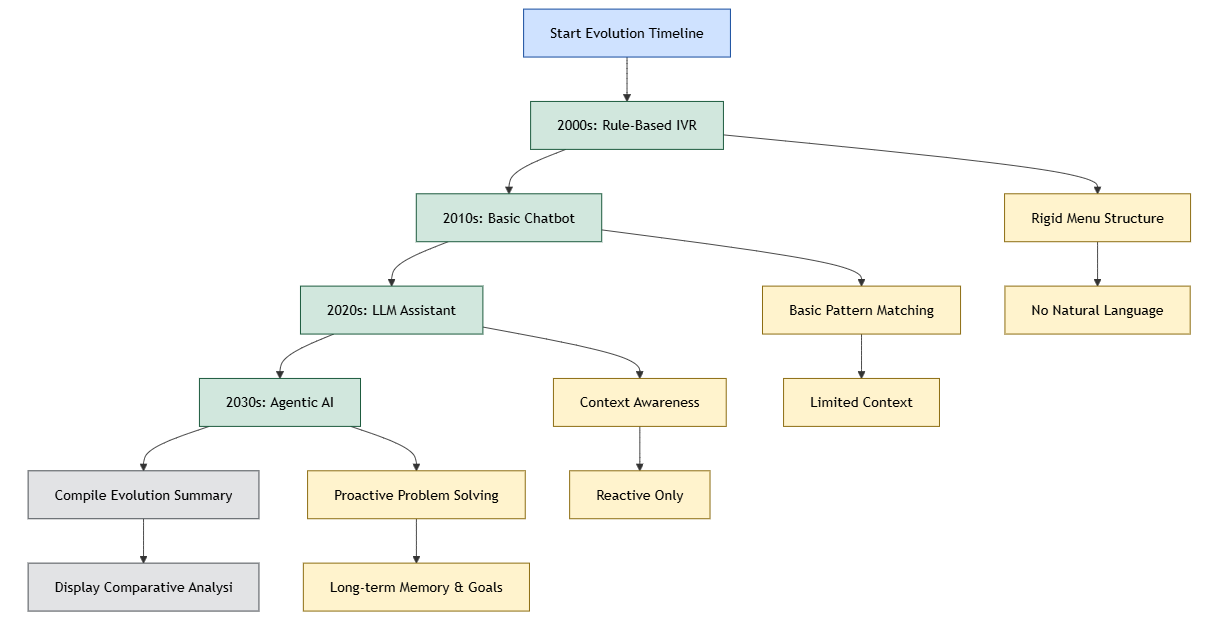

## Desglose del Código Paso a Paso

### Simulación del IVR Basado en Reglas de los Años 2000
- Representa los primeros sistemas de respuesta de voz interactiva con menús jerárquicos rígidos
- Demuestra un manejo de entradas limitado que requiere comandos numéricos o verbales específicos
- Muestra la ausencia total de comprensión del lenguaje natural y de conciencia contextual
- Resalta la frustración de navegar por árboles de opciones predeterminados

### La Era de los Chatbots Básicos de los Años 2010
- Introduce capacidades de procesamiento del lenguaje natural para el reconocimiento de patrones
- Maneja consultas de usuario más complejas y con múltiples problemas mediante coincidencia de palabras clave
- Demuestra una experiencia de usuario mejorada pero con una capacidad limitada de resolución de problemas
- Muestra la dependencia del escalado a agentes humanos para escenarios complejos o desconocidos

### El Avance del Asistente LLM de los Años 2020
- Implementa una comprensión sofisticada del lenguaje y análisis contextual
- Maneja consultas de usuario complejas y de múltiples partes con una comprensión matizada
- Demuestra la capacidad de conectar problemas relacionados y proporcionar soluciones integradas
- Muestra limitaciones en la memoria persistente y el comportamiento proactivo, a pesar de su comprensión avanzada

### La Proyección del Sistema Agéntico de los Años 2030
- Exhibe sistemas con memoria a largo plazo y reconocimiento de patrones históricos
- Demuestra la resolución proactiva de problemas antes de que los usuarios soliciten explícitamente soluciones
- Implementa un comportamiento orientado a objetivos que anticipa las necesidades del usuario
- Presenta el uso autónomo de herramientas y el aprendizaje de preferencias para un servicio personalizado

### Ejecución de la Línea de Tiempo de la Evolución
- Secuencia la progresión histórica en orden cronológico
- Mantiene un ritmo constante entre eras para lograr un efecto dramático
- Recopila los resultados de la simulación de cada era para el análisis comparativo
- Asegura una transición fluida entre décadas para mostrar la progresión tecnológica

### Generación de un Resumen Integral
- Compila las características clave de las cuatro eras en un formato estructurado
- Resalta tanto los avances como las limitaciones de cada tipo de sistema
- Proporciona un análisis comparativo claro de la progresión tecnológica
- Enfatiza la trayectoria desde los sistemas de IA reactivos hacia los proactivos

### Conexión con la Lección
- Progresión Histórica: Ilustra directamente la línea de tiempo, vista en clase, del desarrollo de la IA desde la simple automatización hasta la agencia inteligente
- Trayectoria Tecnológica: Demuestra la ruta de evolución predecible desde reglas deterministas hasta sistemas de aprendizaje adaptativo
- Escalado de Capacidades: Muestra cómo cada década se construyó sobre los avances anteriores a la vez que introducía nuevas limitaciones por superar
- Evolución de la Experiencia de Usuario: Conecta con el contenido de la clase sobre cómo las interfaces de IA pasaron de frustrantes a conversacionales y luego a anticipatorias
- Progresión de la Arquitectura: Ejemplifica el cambio de las máquinas de estados a las redes neuronales y luego a los marcos agénticos discutidos en clase
- Sofisticación en la Resolución de Problemas: Ilustra los conceptos de la clase sobre el paso del tratamiento de síntomas al análisis de causa raíz y a las soluciones preventivas
- Evolución de la Memoria y el Contexto: Demuestra la creciente importancia de la memoria persistente y el contexto histórico en los sistemas de IA
- Restricciones Económicas y Prácticas: Muestra cómo las limitaciones tecnológicas dieron forma a las implementaciones de negocio en cada era
- Metodología de Proyección a Futuro: Proporciona un marco para predecir las trayectorias del desarrollo de la IA basándose en patrones históricos

In [ ]:
# evolution_simulator.py
import time
from datetime import datetime

class AIEvolutionSimulator:
    """
    Simulates the evolution from rule-based to agentic systems.
    """

    def simulate_2000s_rule_based(self):
        """Simulate early 2000s rule-based IVR systems"""
        print("\n📞 2000s: Rule-Based IVR System")
        print("Caller: 'I need help with my bill'")
        time.sleep(1)
        print("System: 'Please say or enter your account number'")
        time.sleep(1)
        print("System: 'For billing questions, press 1. For technical support, press 2...'")
        return {"era": "2000s", "system": "Rule-Based IVR", "limitations": ["Rigid menu structure", "No natural language understanding"]}

    def simulate_2010s_chatbot(self):
        """Simulate 2010s basic chatbots"""
        print("\n💬 2010s: Basic Chatbot")
        print("User: 'My internet is slow and my bill seems too high'")
        time.sleep(1)
        print("Bot: 'I understand you have issues with internet speed and billing.'")
        time.sleep(1)
        print("Bot: 'Let me connect you to a human agent for assistance.'")
        return {"era": "2010s", "system": "Basic Chatbot", "advancements": ["Basic NLP", "Pattern matching"], "limitations": ["Limited context", "No memory"]}

    def simulate_2020s_llm_assistant(self):
        """Simulate 2020s LLM-powered assistants"""
        print("\n🤖 2020s: LLM Assistant")
        print("User: 'My internet has been slow since the storm last week, and my bill is higher than expected'")
        time.sleep(1)
        print("Assistant: 'I understand you're experiencing slow internet after the recent storm and have billing concerns. Let me check for outages in your area and review your bill.'")
        time.sleep(2)
        print("Assistant: 'I see there was an outage in your area that may be affecting service. I also notice your bill includes one-time charges for equipment. Would you like me to explain these charges?'")
        return {"era": "2020s", "system": "LLM Assistant", "advancements": ["Natural language understanding", "Context awareness"], "limitations": ["No persistent memory", "Reactive only"]}

    def simulate_2030s_agentic_system(self):
        """Simulate future agentic systems"""
        print("\n🚀 2030s: Agentic AI System")
        print("User: 'My internet has been slow since the storm last week, and my bill is higher than expected'")
        time.sleep(1)
        print("Agent: 'I recall you had similar issues last year after storms. I'm already checking network status in your area and comparing your current bill to previous patterns.'")
        time.sleep(2)
        print("Agent: 'I detect a pattern - your service often degrades after severe weather. I'm proactively scheduling a technician and applying a loyalty credit to your bill. I'll also research more permanent solutions for your location.'")
        time.sleep(2)
        print("Agent: 'I've updated your account preferences to automatically monitor weather-related service issues. Would you like me to set up proactive alerts?'")
        return {"era": "2030s", "system": "Agentic AI", "advancements": ["Proactive problem-solving", "Long-term memory", "Tool usage", "Goal-oriented behavior"]}

    def run_evolution_simulation(self):
        """Run the complete evolution simulation"""
        print("🕰️ AI EVOLUTION TIMELINE: Customer Service Systems")
        print("=" * 70)

        eras = [
            self.simulate_2000s_rule_based,
            self.simulate_2010s_chatbot,
            self.simulate_2020s_llm_assistant,
            self.simulate_2030s_agentic_system
        ]

        evolution_path = []

        for era_simulation in eras:
            result = era_simulation()
            evolution_path.append(result)
            time.sleep(2)

        # Display evolution summary
        print("\n" + "=" * 70)
        print("EVOLUTION SUMMARY:")
        print("=" * 70)

        for era_info in evolution_path:
            print(f"\n{era_info['era']}: {era_info['system']}")
            if 'advancements' in era_info:
                print(f"Advancements: {', '.join(era_info['advancements'])}")
            if 'limitations' in era_info:
                print(f"Limitations: {', '.join(era_info['limitations'])}")

# Run the evolution simulation
simulator = AIEvolutionSimulator()
simulator.run_evolution_simulation()

🕰️ AI EVOLUTION TIMELINE: Customer Service Systems

📞 2000s: Rule-Based IVR System
Caller: 'I need help with my bill'
System: 'Please say or enter your account number'
System: 'For billing questions, press 1. For technical support, press 2...'

💬 2010s: Basic Chatbot
User: 'My internet is slow and my bill seems too high'
Bot: 'I understand you have issues with internet speed and billing.'
Bot: 'Let me connect you to a human agent for assistance.'

🤖 2020s: LLM Assistant
User: 'My internet has been slow since the storm last week, and my bill is higher than expected'
Assistant: 'I understand you're experiencing slow internet after the recent storm and have billing concerns. Let me check for outages in your area and review your bill.'
Assistant: 'I see there was an outage in your area that may be affecting service. I also notice your bill includes one-time charges for equipment. Would you like me to explain these charges?'

🚀 2030s: Agentic AI System
User: 'My internet has been slow since

<hr>

## 🎓 Guía Didáctica

### Objetivos Clave de Aprendizaje
- Comprender el Espectro: Los estudiantes deben captar el continuo que va desde los sistemas basados en reglas hasta los agénticos
- Identificar Características: Reconocer las funciones clave que definen cada tipo de sistema
- Implementación Práctica: Entender cómo construir sistemas en diferentes puntos del espectro
- Contexto Evolutivo: Apreciar la progresión histórica y la dirección futura

### Puntos de Discusión
- Cuándo usar cada enfoque: Basados en reglas para tareas simples y deterministas; LLM para tareas creativas; agénticos para tareas complejas y orientadas a objetivos
- Compromisos: Complejidad frente a capacidad, determinismo frente a flexibilidad
- Consideraciones Éticas: ¿Cómo impacta una mayor autonomía en la responsabilidad y el control?
- Ejemplos del Mundo Real: Discutir los sistemas actuales con los que interactúan los estudiantes y dónde se ubican en el espectro

### Actividades para el Aula
- Clasificación de Sistemas: Proporcionar ejemplos de sistemas de IA reales y pedir a los estudiantes que los clasifiquen en el espectro
- Reto de Diseño: Dar a los estudiantes un problema y pedirles que diseñen soluciones en diferentes puntos del espectro
- Debate sobre la Evolución: Discutir si todos los sistemas acabarán siendo agénticos, o si siempre habrá lugar para enfoques más simples

### Preguntas de Evaluación
- "¿Qué tres características clave distinguen a la IA agéntica de los LLM básicos?"
- "¿Cuándo elegirías un sistema basado en reglas en lugar de uno impulsado por un LLM?"
- "¿Cómo contribuye la memoria a la agencia en los sistemas de IA?"
- "¿Qué riesgos podrían surgir a medida que los sistemas se vuelven más agénticos?"

Estos ejercicios proporcionan una base concreta para comprender los conceptos fundamentales de la IA Agéntica, a la vez que ofrecen a los estudiantes experiencia práctica con sistemas en diferentes puntos del espectro de autonomía.